### Simple Linear Regression - Project 

In [17]:
# importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [18]:
# reading the dataset
df = pd.read_csv('./height-weight (1).csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

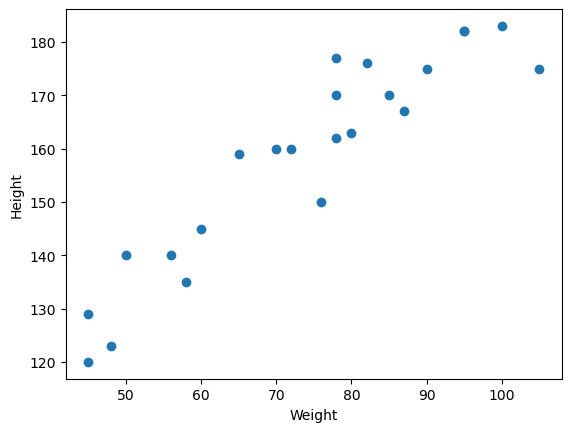

In [19]:
# plotting on scatter plot 
plt.scatter(df['Weight'], df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [20]:
# Divide the dataset into independent and dependent features 
X = df[['Weight']] #independent feature
y = df['Height'] # dependent feature 

In [21]:
# To train test split
from sklearn.model_selection import train_test_split

In [22]:
# 20 records will be used for testing and another records will be used for train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [23]:
# previous records of x without train
X.shape

(23, 1)

In [24]:
# records of x and y after train
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((18, 1), (5, 1), (18,), (5,))

In [25]:
# standardize the dataset - train independent data 
from sklearn.preprocessing import StandardScaler

In [26]:
scaler = StandardScaler()

In [29]:
# training data
X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

d:\anaconda\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


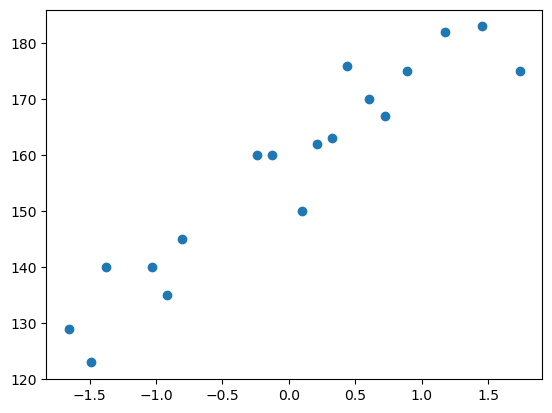

In [30]:
plt.scatter(X_train, y_train)

In [31]:
# train the model using simple linear regression
from sklearn.linear_model import LinearRegression

In [32]:
regressor = LinearRegression()

In [33]:
regressor.fit(X_train, y_train)

LinearRegression()

In [36]:
print("The slope or coefficient of weight is: ", regressor.coef_)
print("Intercept: ", regressor.intercept_)

The slope or coefficient of weight is:  [17.03440872]
Intercept:  157.5


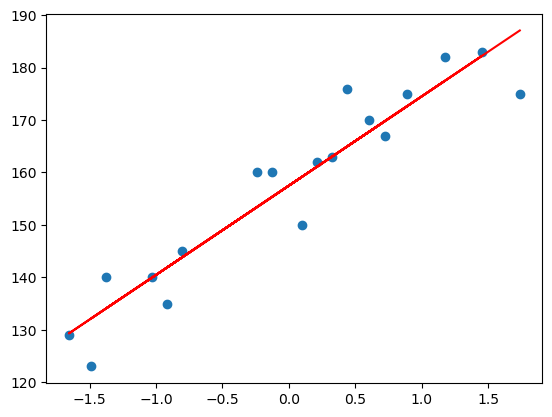

In [ ]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regressor.predict(X_train),'r') #created best fit line by predicting on X_train data

#### Prediction of train data 

1) predicted height output = intercept + coef_(Weights)

2) y_pred_train = 65.4364 + 1.26 (X_train)

#### Prediction of test data 
1) predicted height output = intercept + coef_(Weights)

2) y_pred_test = 65.4364 + 1.26 (X_test)

In [42]:
# prediction for the test data 
y_pred_test = regressor.predict(X_test)

In [43]:
y_pred_test, y_test

(array([1486.18388009, 1486.18388009,  924.04839236, 1775.76882831,
        1264.73656674]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

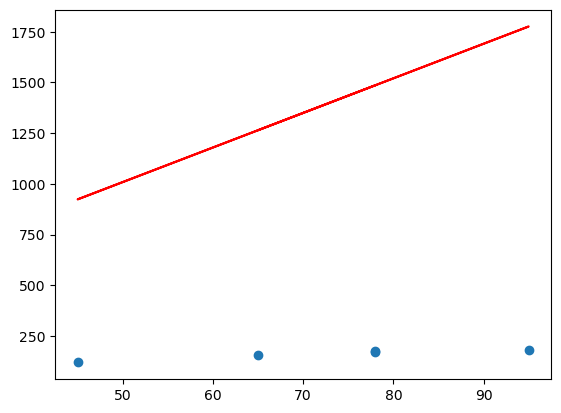

In [45]:
plt.scatter(X_test, y_test)
plt.plot(X_test, regressor.predict(X_test),'r') #created best fit line by predicting on X_train data

#### Performance Metrics

1) MSE, MAE, RMSE

2) R-Square and Adjusted R-Square

In [46]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [48]:
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mse)

print("Mean Squared Error: ", mse)
print("Mean Absolute Error: ", mae)
print("Root Mean Square Error: ", rmse)

Mean Squared Error:  1571109.7376966472
Mean Absolute Error:  1225.7843095186981
Root Mean Square Error:  1253.4391639392186


In [ ]:
# r square
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred_test)

In [51]:
print("the score is: ", score)

the score is:  -3190.755521080463


In [52]:
# adjusted r square
1 - (1 - score) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)

-4254.674028107284